In [24]:
%pip install seaborn
%pip install scikit-learn
%pip install numpy <= 1.25
%pip install mne

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
zsh:1: no such file or directory: =
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np
import os
from scipy import signal
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns



In [26]:
# DOWNLOAD shared google drive into your local device
# Find the folder in your Library/Finder and click copy or copy path
# paste it into file_path

# Drive:
# file_path = '/content/drive/MyDrive/COGS_189_EEG_Data'

file_path = '/Users/earanda/Downloads/COGS_189_EEG_Data'
 
all_X      = []   # will hold (trials, 8, 225) arrays
all_y      = []   # will hold (trials,) binary label arrays
trial_log  = []   # metadata: sub / ses / run / n_trials / n_errors
 
for sub in sorted(os.listdir(file_path)):
    sub_path = os.path.join(file_path, sub)
    if not (os.path.isdir(sub_path) and sub.startswith('sub-')):
        continue
 
    for ses in sorted(os.listdir(sub_path)):
        ses_path = os.path.join(sub_path, ses)
        if not (os.path.isdir(ses_path) and ses.startswith('ses-')):
            continue
 
        # Collect all run numbers present in this session
        run_nums = set()
        for fname in os.listdir(ses_path):
            if fname.startswith('eeg_trials_run-') and fname.endswith('.npy'):
                run_num = fname.replace('eeg_trials_run-', '').replace('.npy', '')
                run_nums.add(run_num)
 
        for run_num in sorted(run_nums):
            trials_path = os.path.join(ses_path, f'eeg_trials_run-{run_num}.npy')
            labels_path = os.path.join(ses_path, f'labels_run-{run_num}.npy')
 
            # Only load if both files exist
            if not (os.path.exists(trials_path) and os.path.exists(labels_path)):
                print(f"  Skipping {sub}/{ses}/run-{run_num} — missing file")
                continue
 
            X_run = np.load(trials_path, allow_pickle=True)   # (trials, 8, 225)
            y_str = np.load(labels_path, allow_pickle=True)   # (trials,) string
 
            # Handle label shape mismatch (trial_metadata has 50 rows, trials 49)
            # Use the shorter length to keep X and y aligned
            n = min(X_run.shape[0], y_str.shape[0])
            X_run = X_run[:n]
            y_str = y_str[:n]
 
            # Binary encode: error=1, correct=0  (A2 Cell 18 convention)
            y_run = (y_str == 'error').astype(int)
 
            n_err = int(np.sum(y_run))
            n_cor = int(np.sum(y_run == 0))
 
            all_X.append(X_run)
            all_y.append(y_run)
            trial_log.append({
                'sub': sub, 'ses': ses, 'run': run_num,
                'n_trials': n, 'n_errors': n_err, 'n_correct': n_cor
            })
            print(f"  Loaded {sub}/{ses}/run-{run_num}: "
                  f"{n} trials  ({n_cor} correct, {n_err} error)")
 
# concat all the runs

# (total_trials, 8, 225)
X_all = np.concatenate(all_X, axis=0) 
# (total_trials,)
y_all = np.concatenate(all_y, axis=0)  
 
total_trials = X_all.shape[0]
total_errors = int(np.sum(y_all))
total_correct = int(np.sum(y_all == 0))
 
print(f"  Total runs loaded: {len(trial_log)}")
print(f"  Total trials: {total_trials}")
print(f"  Total correct: {total_correct}  ({100*total_correct/total_trials:.1f}%)")
print(f"  Total errors: {total_errors}   ({100*total_errors/total_trials:.1f}%)")
print(f"  X shape: {X_all.shape}")
print(f"  y shape: {y_all.shape}")
 
#parameters for dataset
fs               = 250.0       # Hz
dt               = 1000. / fs  # ms (A1 Cell 39)
sdt              = int(round(dt))
epoch_start_ms   = -500
epoch_end_ms     =  400
pre_start_ms     = -500
pre_end_ms       =   0
baseline_start_ms = -500
baseline_end_ms   = -400
 
pre_s = np.round((pre_start_ms  - epoch_start_ms) / sdt).astype(int)   # 0
pre_e = np.round((pre_end_ms    - epoch_start_ms) / sdt).astype(int)   # 125
bl_s  = np.round((baseline_start_ms - epoch_start_ms) / sdt).astype(int)
bl_e  = np.round((baseline_end_ms   - epoch_start_ms) / sdt).astype(int)
 
channel_names = ['Fz','F3','Cz','C3','C4','Pz','O1','O2']
times_ms = np.linspace(epoch_start_ms, epoch_end_ms, X_all.shape[2])
 
err_idx = np.where(y_all == 1)[0]
cor_idx = np.where(y_all == 0)[0]


  Loaded sub-01/ses-01/run-01: 49 trials  (43 correct, 6 error)
  Loaded sub-01/ses-01/run-02: 50 trials  (44 correct, 6 error)
  Loaded sub-01/ses-01/run-03: 50 trials  (44 correct, 6 error)
  Loaded sub-01/ses-01/run-04: 50 trials  (43 correct, 7 error)
  Loaded sub-02/ses-01/run-01: 50 trials  (48 correct, 2 error)
  Loaded sub-02/ses-01/run-02: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-01/run-03: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-01/run-04: 50 trials  (46 correct, 4 error)
  Loaded sub-02/ses-02/run-01: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-02/run-02: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-02/run-03: 50 trials  (46 correct, 4 error)
  Loaded sub-02/ses-02/run-04: 50 trials  (49 correct, 1 error)
  Loaded sub-02/ses-02/run-05: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-02/run-06: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-02/run-07: 49 trials  (46 correct, 3 error)
  Loaded sub-02/ses-02/run-08: 50 trials

In [27]:
# baseline correction for 3D EEG data
# takes value and subtracts it by the mean of all X values, to normalize it around 0
FS = 250.0       # Hz
dt = 1000. / FS  # ms 
sdt = int(round(dt))
epoch_start_ms = -500
epoch_end_ms = 400
baseline_start_ms = -500
baseline_end_ms = -400

# Convert ms to indices
bl_s  = np.round((baseline_start_ms - epoch_start_ms) / sdt).astype(int)
bl_e  = np.round((baseline_end_ms   - epoch_start_ms) / sdt).astype(int)
 
# Baseline correction
X_bl = X_all.copy()
for i in range(X_bl.shape[0]):              
    for ch in range(X_bl.shape[1]):
        X_bl[i, ch, :] = X_bl[i, ch, :] - np.mean(X_bl[i, ch, bl_s:bl_e])

print(f"Baseline corrected shape: {X_bl.shape}")

Baseline corrected shape: (798, 8, 225)


In [28]:
# ── Filtering ──────────────────────────────────────────────────────────────────
# We apply a 40 Hz lowpass only.
#
# Why no highpass:
#   flanker.py already attempted a 1–40 Hz bandpass on each epoch, but it
#   epoched first (225 samples) then filtered — the wrong order. A 1 Hz FIR
#   highpass needs ~1650 samples at 250 Hz to work. MNE padded the 225-sample
#   epochs with edge reflections instead of filtering properly.
#   Applying another highpass here would compound that distortion.
#   Baseline correction (already applied) handles DC drift instead.
#
# Why 40 Hz lowpass is fine:
#   A 40 Hz lowpass only needs ~165 samples — well within our 225-sample epoch.
#   This removes high-frequency muscle noise above our bands of interest
#   (theta 4–7, alpha 8–12, beta 13–30 Hz).
#
# Why not re-run the full bandpass on raw:
#   flanker.py never saved stim_onset_sample or press_sample to metadata,
#   so we cannot reconstruct response-locked epochs from eeg_raw_run-XX.npy.

from scipy.signal import butter, sosfiltfilt
from scipy.signal import detrend

def lowpass_40hz(data, fs=250.0, order=4):
    """
    Zero-phase Butterworth lowpass at 40 Hz.
    Works on 3D array (trials, channels, samples) via axis=-1.
    Order 4 gives good rolloff while staying numerically stable on short epochs.
    """
    nyq = 0.5 * fs
    sos = butter(order, 40.0 / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, data, axis=-1)

X_clean = lowpass_40hz(detrend(X_bl, axis=-1).astype(float))
print(f'Filtered shape: {X_clean.shape}')
print(f'Applied: 40 Hz lowpass (Butterworth order 4, zero-phase)')
print(f'Bands preserved: theta (4-7), alpha (8-12), beta (13-30) Hz — all intact')

Filtered shape: (798, 8, 225)
Applied: 40 Hz lowpass (Butterworth order 4, zero-phase)
Bands preserved: theta (4-7), alpha (8-12), beta (13-30) Hz — all intact


In [29]:
THRESHOLD = 150.0  # µV

# # Find trials where the maximum absolute amplitude is below the threshold
# valid_trial_indices = []
# for i in range(X_clean.shape[0]):
#     if np.max(np.abs(X_clean[i, :, :])) < THRESHOLD:
#         valid_trial_indices.append(i)

# # Overwrite X and y to only keep the clean trials
# X_clean = X_clean[valid_trial_indices]
# y_all = y_all[valid_trial_indices]

# print(f"Dropped {len(y_all) - len(valid_trial_indices)} noisy trials.")
# print(f"Clean trials remaining: {X_clean.shape[0]}")


n_total = X_clean.shape[0]   # ← save BEFORE overwriting
valid_trial_indices = [
    i for i in range(n_total)
    if np.max(np.abs(X_clean[i])) < THRESHOLD
]

X_clean = X_clean[valid_trial_indices]
y_all   = y_all[valid_trial_indices]

n_dropped = n_total - len(valid_trial_indices)   # ← now correct
print(f'Threshold: ±{THRESHOLD} µV')
print(f'Dropped {n_dropped}/{n_total} trials ({100*n_dropped/n_total:.1f}%)')
print(f'Clean trials remaining: {X_clean.shape[0]}')
print(f'Errors remaining: {y_all.sum()} | Correct: {(y_all==0).sum()}')

Threshold: ±150.0 µV
Dropped 160/798 trials (20.1%)
Clean trials remaining: 638
Errors remaining: 59 | Correct: 579


  ARTIFACT REJECTION REPORT  (threshold = ±150.0 µV)
  Total trials   : 798
  Kept           : 638  (79.9%)
  Dropped        : 160  (20.1%)
    Correct dropped : 142
    Error   dropped : 18

  Which channel triggered each drop:
    Fz     80  ████████████████████████████████████████████████████████████████████████████████
    F3      5  █████
    Cz      2  ██
    C4     72  ████████████████████████████████████████████████████████████████████████
    O1      1  █

  Dropped trial details:
   Trial    Label    Max µV   Worst ch
  ----------------------------------------
       0  correct     201.8         C4
       1  correct     219.8         C4
       2  correct     209.0         C4
       3    error     220.4         C4  ← ERROR
       4  correct     161.6         C4
       5  correct     194.6         C4
       6  correct     192.2         C4
       7    error     159.7         Fz  ← ERROR
       8  correct     214.4         Fz
       9  correct     209.2         Fz
      10    err

/var/folders/46/yc4496mx77g8716fqwx2phsr0000gn/T/ipykernel_21086/426146041.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_by_ch, labels=CHANNEL_NAMES_LOCAL,


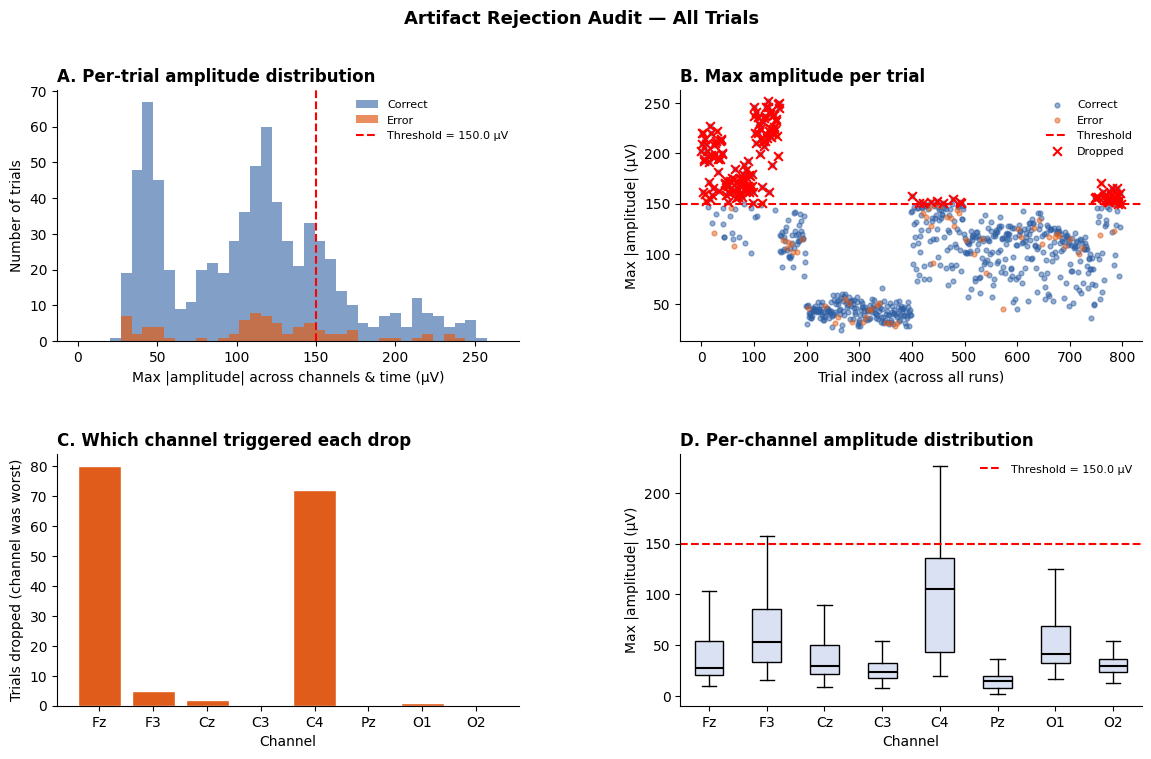

In [30]:
# ── Trial Drop Inspector ──────────────────────────────────────────────────────
# Shows exactly which trials were dropped, why, and what the amplitude
# distribution looks like — so you can audit the artifact rejection threshold.
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

CHANNEL_NAMES_LOCAL = ["Fz", "F3", "Cz", "C3", "C4", "Pz", "O1", "O2"]

# Recompute per-trial stats on the full (pre-rejection) filtered array.
# We need X_all_filt — the filtered data before X_clean was overwritten.
# Reconstruct: re-filter X_bl (still in memory).
_X_dt   = __import__('scipy.signal', fromlist=['detrend']).detrend(X_bl, axis=-1)
from scipy.signal import butter, sosfiltfilt
_sos    = butter(4, 40.0 / (0.5 * FS), btype='low', output='sos')
_X_filt = sosfiltfilt(_sos, _X_dt.astype(float), axis=-1)

_n_total          = _X_filt.shape[0]
_per_trial_max    = np.abs(_X_filt).max(axis=(1, 2))        # (n_trials,)
_per_ch_max       = np.abs(_X_filt).max(axis=2)             # (n_trials, 8)
_offending_ch     = _per_ch_max.argmax(axis=1)              # which channel was worst
_dropped_mask     = _per_trial_max >= THRESHOLD
_dropped_indices  = np.where(_dropped_mask)[0]
_kept_indices     = np.where(~_dropped_mask)[0]

# y_all was already filtered, so index into the original y before filtering.
# We stored it as y_all (post-rejection). Reconstruct original labels:
_y_orig = np.concatenate([
    np.load(lp, allow_pickle=True)
    for lp in sorted(
        __import__('glob').glob(__import__('os').path.join(file_path, 'sub-*', 'ses-*', 'labels_run-*.npy'))
    )
])
_n = min(len(_y_orig), _n_total)
_y_orig = (_y_orig[:_n] == 'error').astype(int)

print(f"{'='*55}")
print(f"  ARTIFACT REJECTION REPORT  (threshold = ±{THRESHOLD} µV)")
print(f"{'='*55}")
print(f"  Total trials   : {_n_total}")
print(f"  Kept           : {(~_dropped_mask).sum()}  "
      f"({100*(~_dropped_mask).mean():.1f}%)")
print(f"  Dropped        : {_dropped_mask.sum()}  "
      f"({100*_dropped_mask.mean():.1f}%)")
print(f"    Correct dropped : {(_dropped_mask & (_y_orig==0)).sum()}")
print(f"    Error   dropped : {(_dropped_mask & (_y_orig==1)).sum()}")
print()

print(f"  Which channel triggered each drop:")
for ci, ch in enumerate(CHANNEL_NAMES_LOCAL):
    n = ((_offending_ch == ci) & _dropped_mask).sum()
    if n > 0:
        bar = "█" * n
        print(f"    {ch:<4}  {n:>3}  {bar}")
print()

print(f"  Dropped trial details:")
print(f"  {'Trial':>6}  {'Label':>7}  {'Max µV':>8}  {'Worst ch':>9}")
print(f"  {'-'*40}")
for idx in _dropped_indices:
    lbl  = "error" if _y_orig[idx] == 1 else "correct"
    mx   = _per_trial_max[idx]
    wch  = CHANNEL_NAMES_LOCAL[_offending_ch[idx]]
    flag = "  ← ERROR" if _y_orig[idx] == 1 else ""
    print(f"  {idx:>6}  {lbl:>7}  {mx:>8.1f}  {wch:>9}{flag}")

# ── Figure: amplitude distribution + dropped trials ──────────────────────────
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: histogram of per-trial max amplitudes
ax0 = fig.add_subplot(gs[0, 0])
cor_amps = _per_trial_max[_y_orig == 0]
err_amps = _per_trial_max[_y_orig == 1]
bins = np.linspace(0, _per_trial_max.max() * 1.05, 40)
ax0.hist(cor_amps, bins=bins, alpha=0.6, color='#2E5FA3', label='Correct')
ax0.hist(err_amps, bins=bins, alpha=0.7, color='#E05C1A', label='Error')
ax0.axvline(THRESHOLD, color='red', ls='--', lw=1.5,
            label=f'Threshold = {THRESHOLD} µV')
ax0.set_xlabel('Max |amplitude| across channels & time (µV)')
ax0.set_ylabel('Number of trials')
ax0.set_title('A. Per-trial amplitude distribution', fontweight='bold', loc='left')
ax0.legend(fontsize=8, frameon=False)
ax0.spines[['top', 'right']].set_visible(False)

# Panel B: scatter — trial index vs max amplitude, colour by label
ax1 = fig.add_subplot(gs[0, 1])
for lbl_val, color, name in [(0, '#2E5FA3', 'Correct'), (1, '#E05C1A', 'Error')]:
    mask = _y_orig == lbl_val
    ax1.scatter(np.where(mask)[0], _per_trial_max[mask],
                s=12, alpha=0.5, color=color, label=name)
ax1.axhline(THRESHOLD, color='red', ls='--', lw=1.5,
            label=f'Threshold')
# mark dropped
ax1.scatter(_dropped_indices, _per_trial_max[_dropped_indices],
            s=40, marker='x', color='red', zorder=5, label='Dropped')
ax1.set_xlabel('Trial index (across all runs)')
ax1.set_ylabel('Max |amplitude| (µV)')
ax1.set_title('B. Max amplitude per trial', fontweight='bold', loc='left')
ax1.legend(fontsize=8, frameon=False)
ax1.spines[['top', 'right']].set_visible(False)

# Panel C: per-channel bar chart of how many drops each channel caused
ax2 = fig.add_subplot(gs[1, 0])
drop_per_ch = [
    ((_offending_ch == ci) & _dropped_mask).sum()
    for ci in range(len(CHANNEL_NAMES_LOCAL))
]
bar_colors = ['#E05C1A' if v > 0 else '#BBBBBB' for v in drop_per_ch]
ax2.bar(CHANNEL_NAMES_LOCAL, drop_per_ch, color=bar_colors, edgecolor='white')
ax2.set_xlabel('Channel')
ax2.set_ylabel('Trials dropped (channel was worst)')
ax2.set_title('C. Which channel triggered each drop', fontweight='bold', loc='left')
ax2.spines[['top', 'right']].set_visible(False)

# Panel D: per-channel max amplitude (box plot)
ax3 = fig.add_subplot(gs[1, 1])
data_by_ch = [_per_ch_max[:, ci] for ci in range(len(CHANNEL_NAMES_LOCAL))]
bp = ax3.boxplot(data_by_ch, labels=CHANNEL_NAMES_LOCAL,
                 patch_artist=True, showfliers=False,
                 medianprops=dict(color='black', lw=1.5))
for patch in bp['boxes']: patch.set_facecolor('#D9E1F2')
ax3.axhline(THRESHOLD, color='red', ls='--', lw=1.5,
            label=f'Threshold = {THRESHOLD} µV')
ax3.set_xlabel('Channel')
ax3.set_ylabel('Max |amplitude| (µV)')
ax3.set_title('D. Per-channel amplitude distribution', fontweight='bold', loc='left')
ax3.legend(fontsize=8, frameon=False)
ax3.spines[['top', 'right']].set_visible(False)

fig.suptitle('Artifact Rejection Audit — All Trials', fontsize=13, fontweight='bold')
plt.show()


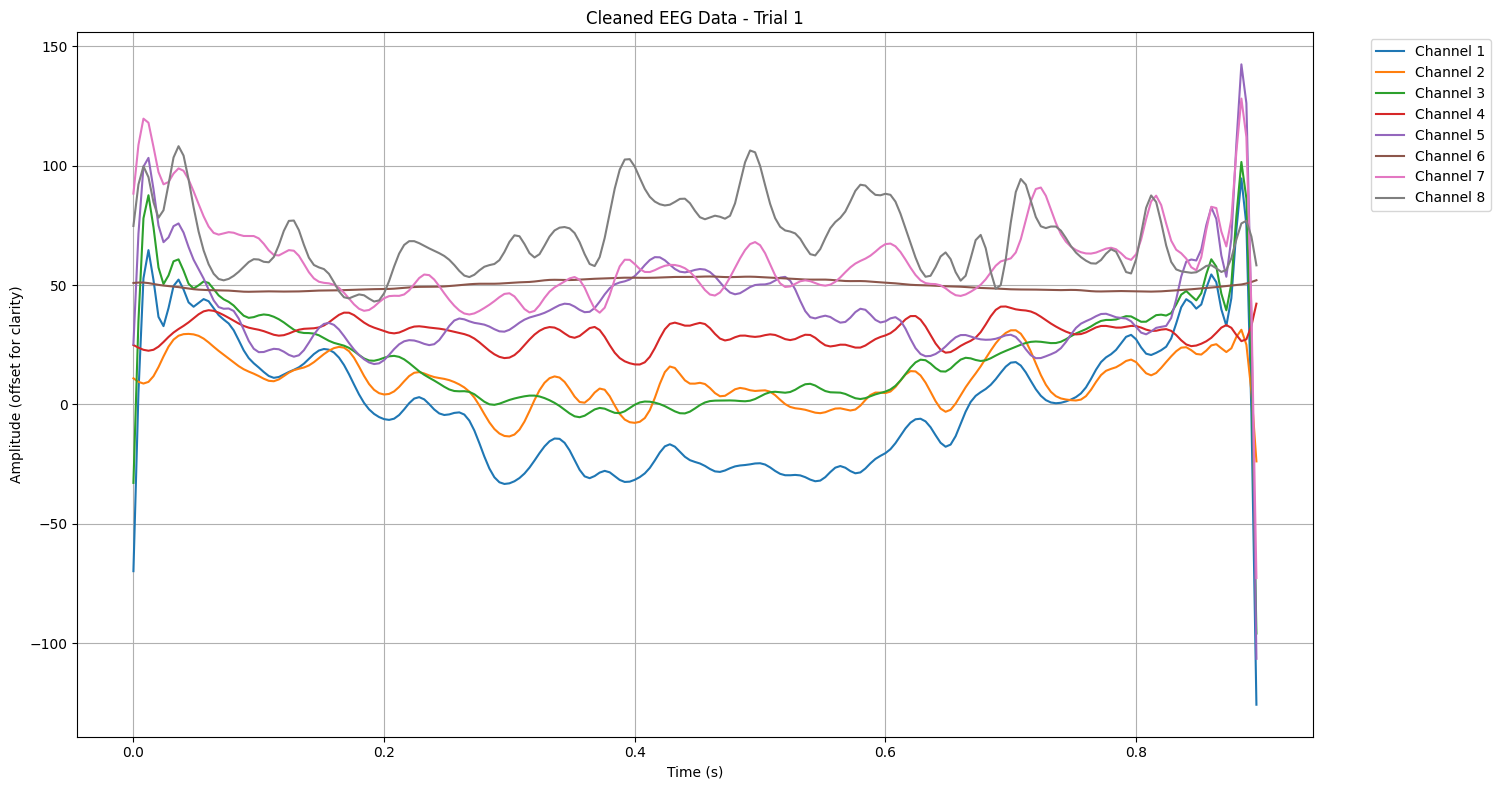

In [31]:

trial_index = 0
single_trial_data = X_clean[trial_index, :, :]

num_channels, num_time_points = single_trial_data.shape
time = np.arange(num_time_points) / FS

plt.figure(figsize=(15, 8))

for i in range(num_channels):
    # Offset each channel by i*10 so they don't overlap
    plt.plot(time, single_trial_data[i, :] + i * 10, label=f'Channel {i+1}') 

plt.title(f'Cleaned EEG Data - Trial {trial_index + 1}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (offset for clarity)')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# # Filtering
# bands = {
#     'theta': (4,  7),
#     'alpha': (8, 12),
#     'beta' : (13, 30),
# }
# num_taps = 31   # A2 Cell 14

# X_bands = {}
# for band_name, (hp, lp) in bands.items():
#     b = signal.firwin(numtaps=num_taps, cutoff=[hp, lp],
#                       pass_zero='bandpass', fs=fs)   # A2 Cell 14
#     a = 1                                             # A2 Cell 14: "for FIR filters, a is always 1"

#     X_filt = np.zeros_like(X_bl)
#     for i in range(X_bl.shape[0]):          # A2 Cell 18: loop over trials
#         for ch in range(X_bl.shape[1]):
#             X_filt[i, ch, :] = signal.filtfilt(b, a, X_bl[i, ch, :])  # A2 Cell 18

#     X_bands[band_name] = X_filt
#     print(f"  [{band_name}] ({hp}–{lp} Hz): {X_filt.shape}")


In [33]:
CHANNEL_NAMES = ["Fz", "F3", "Cz", "C3", "C4", "Pz", "O1", "O2"]
BANDS = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta": (13, 30),
}

def bandpower_1d(x, fs, band, nperseg=None):
    low, high = band
    nperseg = min(len(x), 128) if nperseg is None else nperseg

    freqs, psd = welch(x, fs=fs, nperseg=nperseg)
    mask = (freqs >= low) & (freqs <= high)

    if not np.any(mask): return np.nan

    selected_freqs = freqs[mask]
    selected_psd = psd[mask]

    if selected_freqs.size == 1:
        freq_res = freqs[1] - freqs[0]
        return float(selected_psd[0] * freq_res)

    return float(np.trapz(selected_psd, selected_freqs))

def extract_bandpower_features(trials, labels, fs=FS, channel_names=CHANNEL_NAMES, bands=BANDS):
    rows = []
    for trial_idx in range(trials.shape[0]):
        row = {
            "trial": trial_idx,
            "label": "error" if labels[trial_idx] == 1 else "correct"
        }
        trial = trials[trial_idx]

        for ch_idx, ch_name in enumerate(channel_names):
            sig = trial[ch_idx]
            for band_name, band_range in bands.items():
                row[f"{band_name}_{ch_name}"] = bandpower_1d(sig, fs, band_range)

        rows.append(row)

    return pd.DataFrame(rows)

#new-addition, stop right before 0

# Assuming times_ms is an array from -500 to +400
zero_index = np.argmin(np.abs(times_ms - 0))

# Slice the data to only include -500ms to 0ms
X_pre_response = X_clean[:, :, :zero_index]

# NOW run the feature extraction on the sliced data
feature_table_df = extract_bandpower_features(X_pre_response, y_all)

# Generate features directly from memory
# feature_table_df = extract_bandpower_features(X_clean, y_all)

display(feature_table_df.head(10))

/var/folders/46/yc4496mx77g8716fqwx2phsr0000gn/T/ipykernel_21086/519871729.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(selected_psd, selected_freqs))


,trial,label,theta_Fz,alpha_Fz,beta_Fz,theta_F3,alpha_F3,beta_F3,theta_Cz,alpha_Cz,...,beta_C4,theta_Pz,alpha_Pz,beta_Pz,theta_O1,alpha_O1,beta_O1,theta_O2,alpha_O2,beta_O2
0,0,correct,14.232040,14.622384,7.618031,9.217877,12.067009,6.757146,6.823907,1.004675,...,5.695269,0.154766,0.000679,0.011491,5.810662,4.599791,9.211635,6.985837,13.841531,12.078072
1,1,correct,6.773518,8.869673,11.112198,2.735688,11.462197,13.468453,4.995003,2.832625,...,5.023013,0.136741,0.001783,0.006174,3.610007,3.670317,7.315396,4.220521,4.515142,17.636363
2,2,error,11.128149,30.111439,10.704410,1.478316,35.974233,8.933573,4.628352,3.470314,...,6.556135,0.148863,0.001479,0.008740,18.727146,1.711483,3.898899,38.022726,0.553468,10.839251
3,3,correct,2.407209,1.719121,4.550935,0.748235,3.581740,4.875160,4.052817,1.399030,...,4.614964,0.127222,0.001723,0.005403,6.556009,1.044115,5.271453,1.416235,6.234191,8.961904
4,4,correct,12.786848,7.366643,5.483345,7.283408,3.604078,9.975029,2.424626,2.563639,...,1.764263,0.098546,0.001678,0.003757,5.271740,3.705078,9.678257,4.787536,7.254371,7.386978
5,5,correct,27.457583,109.661970,4.256807,8.430735,96.936322,4.634610,7.753975,10.718701,...,7.359678,0.109191,0.001383,0.005410,9.725521,17.659060,2.881513,7.551717,47.948847,28.070901
6,6,correct,10.965338,40.657503,8.847026,3.285011,37.480585,10.668862,4.460962,8.777285,...,8.014844,0.116681,0.001994,0.010659,13.884324,3.788014,13.971892,7.960094,57.735140,9.403957
7,7,correct,51.258418,32.111667,18.161741,35.322821,35.194142,13.700836,17.809396,15.315372,...,5.627421,0.108426,0.002817,0.002292,17.101445,8.050162,16.389769,26.925375,18.897586,14.417319
8,8,correct,7.952474,4.386034,13.793785,1.969775,2.496617,8.023948,4.508794,1.725501,...,7.623070,0.081123,0.001540,0.005304,5.900792,20.929633,7.054422,0.873317,19.549713,12.517640
9,9,error,14.090009,6.048617,12.828217,21.346808,9.019024,10.237593,5.139123,0.249378,...,3.917711,0.068776,0.000714,0.008793,4.265721,12.260173,2.304917,7.259630,23.016717,11.555568


Feature matrix : (638, 24)
Labels         : (638,)
Correct: 579  |  Error: 59  (9.2% errors)
  Fold 1  AUC=0.566    errors in test: 12/128
  Fold 2  AUC=0.474    errors in test: 12/128
  Fold 3  AUC=0.601    errors in test: 12/128
  Fold 4  AUC=0.310    errors in test: 11/127
  Fold 5  AUC=0.547    errors in test: 12/127

── Classification Report (5-Fold CV) ──
              precision    recall  f1-score   support

     Correct       0.92      0.72      0.81       579
       Error       0.12      0.37      0.18        59

    accuracy                           0.69       638
   macro avg       0.52      0.55      0.49       638
weighted avg       0.84      0.69      0.75       638

Mean ROC-AUC : 0.500 ± 0.103
Overall AUC  : 0.489


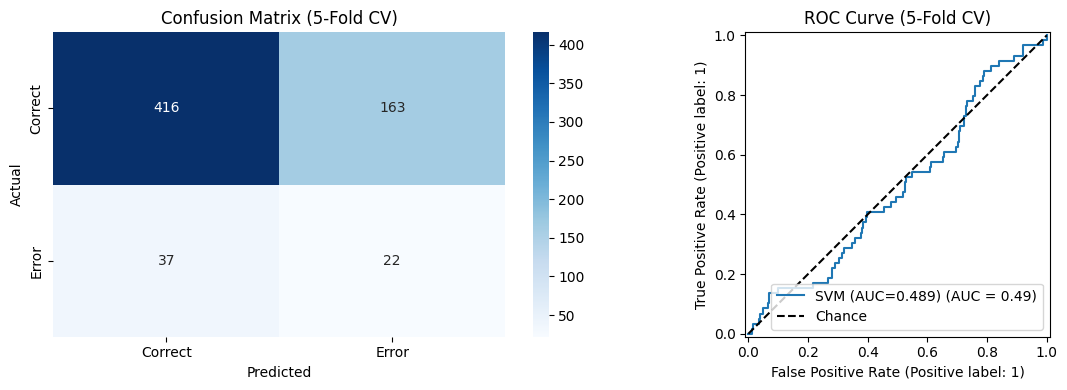

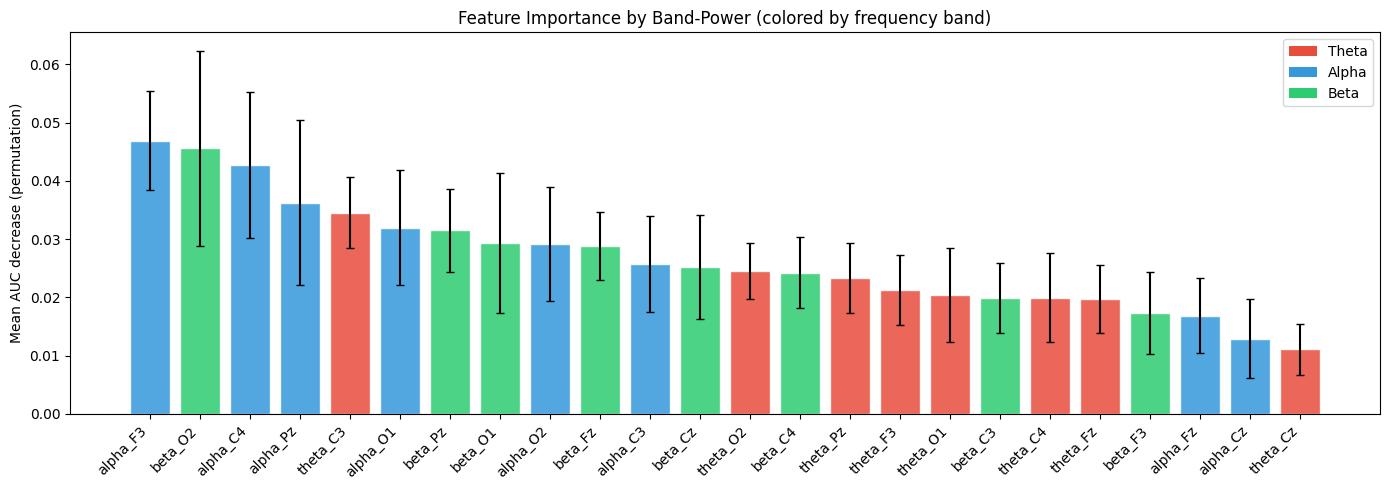

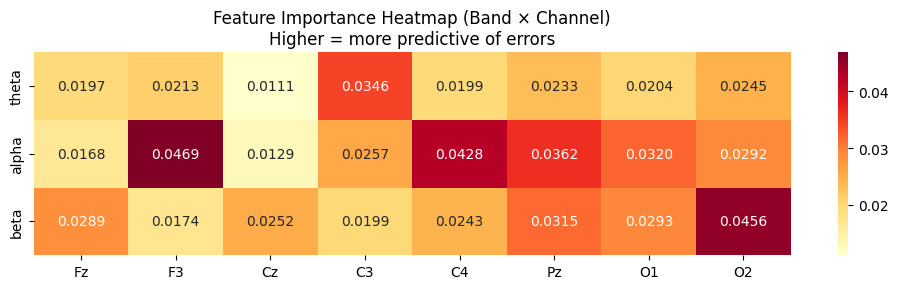


Top 10 most predictive features:
Rank  Feature                Importance        ±Std
────────────────────────────────────────────────────
1     alpha_F3                   0.0469      0.0084
2     beta_O2                    0.0456      0.0168
3     alpha_C4                   0.0428      0.0125
4     alpha_Pz                   0.0362      0.0141
5     theta_C3                   0.0346      0.0061
6     alpha_O1                   0.0320      0.0098
7     beta_Pz                    0.0315      0.0072
8     beta_O1                    0.0293      0.0120
9     alpha_O2                   0.0292      0.0098
10    beta_Fz                    0.0289      0.0059


In [34]:

# 1. PREPARE FEATURE MATRIX FROM YOUR EXISTING feature_table_df

# Drop metadata columns — keep only the 24 band-power features
feature_cols = [c for c in feature_table_df.columns
                if c not in ('trial', 'label')]

X_feat = feature_table_df[feature_cols].values.astype(float)  
y      = (feature_table_df['label'] == 'error').astype(int).values 

print(f"Feature matrix : {X_feat.shape}")
print(f"Labels         : {y.shape}")
print(f"Correct: {(y==0).sum()}  |  Error: {(y==1).sum()}  "
      f"({100*y.mean():.1f}% errors)")

# 2. STRATIFIED K-FOLD SVM
# - Stratified: preserves ~10% error ratio in every fold
# - class_weight='balanced': automatically up-weights the rare error class
# - probability=True: needed for AUC scoring

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

all_true, all_preds, all_probs = [], [], []
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_feat, y)):
    X_train, X_test = X_feat[train_idx], X_feat[test_idx]
    y_train, y_test = y[train_idx],      y[test_idx]

    # Scale INSIDE the fold — no data leakage
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    svm = SVC(kernel='rbf', class_weight='balanced',
              probability=True, random_state=42)
    svm.fit(X_train, y_train)

    preds = svm.predict(X_test)
    probs = svm.predict_proba(X_test)[:, 1]   # P(error)

    fold_auc = roc_auc_score(y_test, probs)
    fold_aucs.append(fold_auc)

    all_true.extend(y_test)
    all_preds.extend(preds)
    all_probs.extend(probs)

    print(f"  Fold {fold+1}  AUC={fold_auc:.3f}  "
          f"  errors in test: {y_test.sum()}/{len(y_test)}")

# 3. METRICS

print("\n── Classification Report (5-Fold CV) ──")
print(classification_report(all_true, all_preds,
                             target_names=['Correct', 'Error']))
print(f"Mean ROC-AUC : {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")
print(f"Overall AUC  : {roc_auc_score(all_true, all_probs):.3f}")

# 4. CONFUSION MATRIX 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Correct','Error'],
            yticklabels=['Correct','Error'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (5-Fold CV)')

# ROC Curve
RocCurveDisplay.from_predictions(all_true, all_probs, ax=axes[1],
                                  name=f"SVM (AUC={roc_auc_score(all_true, all_probs):.3f})")
axes[1].plot([0,1],[0,1],'k--', label='Chance')
axes[1].set_title('ROC Curve (5-Fold CV)')
axes[1].legend()
plt.tight_layout()
plt.show()

# 5. FEATURE IMPORTANCE 
# Retrain on ALL data for stable importance estimates

X_all_scaled = StandardScaler().fit_transform(X_feat)
svm_full = SVC(kernel='rbf', class_weight='balanced',
               probability=True, random_state=42)
svm_full.fit(X_all_scaled, y)

result = permutation_importance(
    svm_full, X_all_scaled, y,
    n_repeats=50, random_state=42, scoring='roc_auc'
)

imp_mean = result.importances_mean
imp_std  = result.importances_std
sorted_idx = np.argsort(imp_mean)[::-1]

# 6. IMPORTANCE PLOT — organized by band 
# Color-code by band so you can immediately see theta vs alpha vs beta patterns

band_colors = {
    'theta': '#E74C3C',   # red
    'alpha': '#3498DB',   # blue
    'beta' : '#2ECC71',   # green
}

def get_band(feat_name):
    for b in band_colors:
        if feat_name.startswith(b):
            return b
    return 'other'

sorted_names  = [feature_cols[i] for i in sorted_idx]
sorted_means  = imp_mean[sorted_idx]
sorted_stds   = imp_std[sorted_idx]
colors        = [band_colors[get_band(n)] for n in sorted_names]

plt.figure(figsize=(14, 5))
bars = plt.bar(range(len(sorted_names)), sorted_means,
               yerr=sorted_stds, capsize=3,
               color=colors, alpha=0.85, edgecolor='white')

plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha='right')
plt.ylabel('Mean AUC decrease (permutation)')
plt.title('Feature Importance by Band-Power (colored by frequency band)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=b.capitalize())
                   for b, c in band_colors.items()]
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

# 7. HEATMAP — importance as (band × channel) grid 
# This is the most interpretable view for your neuroscience question

CHANNEL_NAMES = ["Fz","F3","Cz","C3","C4","Pz","O1","O2"]
BAND_NAMES    = ["theta","alpha","beta"]

imp_grid = np.zeros((len(BAND_NAMES), len(CHANNEL_NAMES)))
for i, col in enumerate(feature_cols):
    for b_idx, band in enumerate(BAND_NAMES):
        if col.startswith(band):
            ch = col.split('_', 1)[1]
            c_idx = CHANNEL_NAMES.index(ch)
            imp_grid[b_idx, c_idx] = imp_mean[i]

plt.figure(figsize=(10, 3))
sns.heatmap(imp_grid, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=CHANNEL_NAMES, yticklabels=BAND_NAMES)
plt.title('Feature Importance Heatmap (Band × Channel)\nHigher = more predictive of errors')
plt.tight_layout()
plt.show()

# 8. TOP FEATURES SUMMARY 

print("\nTop 10 most predictive features:")
print(f"{'Rank':<5} {'Feature':<20} {'Importance':>12}  {'±Std':>10}")
print("─" * 52)
for rank, idx in enumerate(sorted_idx[:10], 1):
    print(f"{rank:<5} {feature_cols[idx]:<20} "
          f"{imp_mean[idx]:>12.4f}  {imp_std[idx]:>10.4f}")

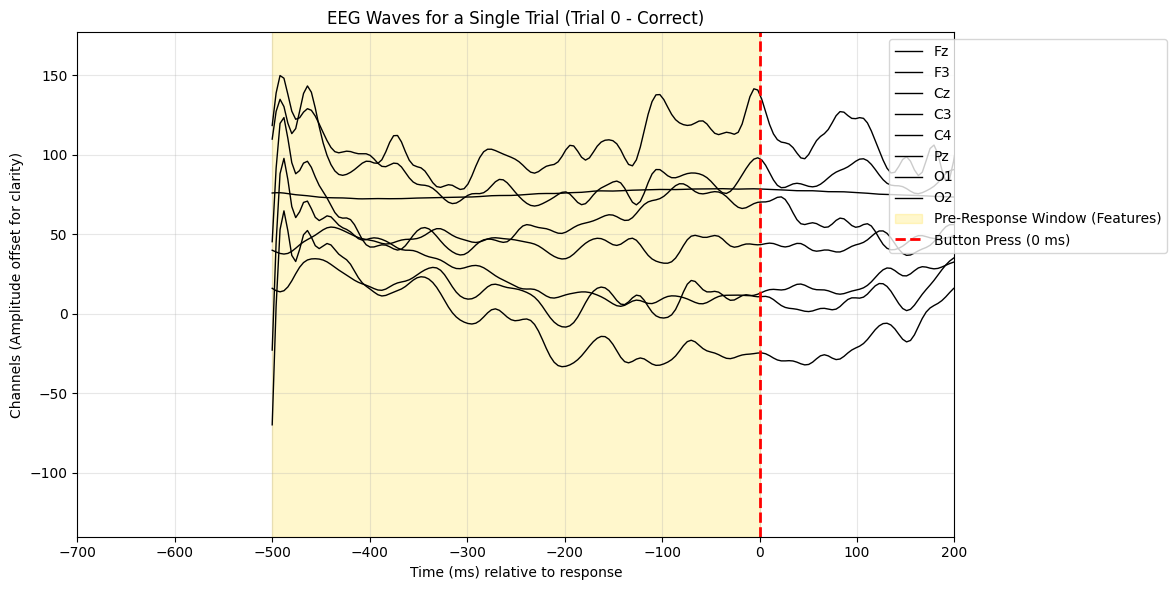

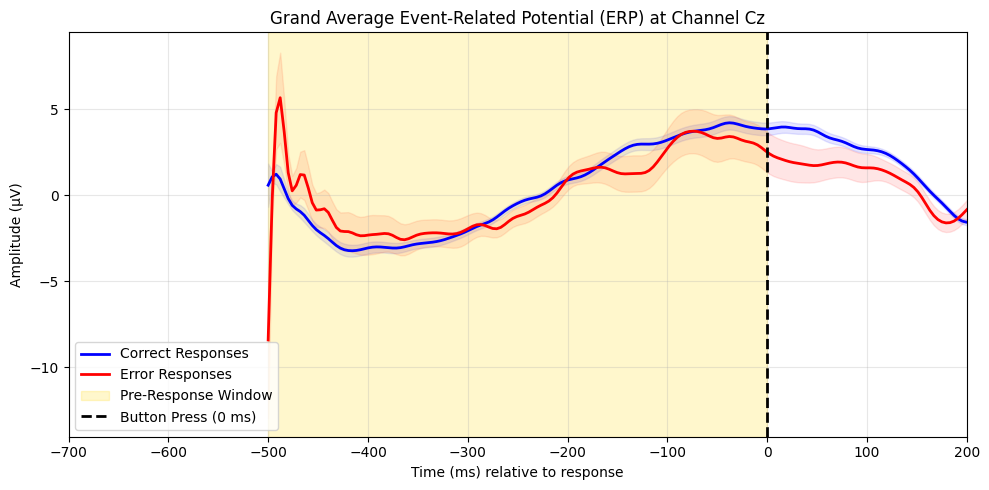

In [35]:
# Gemini-Assisted Code

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Plot 1: Single Trial Brainwaves (All Channels)
# ---------------------------------------------------------
trial_idx = 0  # Change this number to look at different trials
single_trial = X_clean[trial_idx]
actual_outcome = "Error" if y_all[trial_idx] == 1 else "Correct"

plt.figure(figsize=(12, 6))

for i, ch_name in enumerate(CHANNEL_NAMES):
    # Offset each channel by 15 microvolts so they don't overlap
    plt.plot(times_ms, single_trial[i] + (i * 15), label=ch_name, color='black', linewidth=1)

# Highlight the Pre-Response Window (-500ms to 0ms)
plt.axvspan(-500, 0, color='gold', alpha=0.2, label='Pre-Response Window (Features)')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Button Press (0 ms)')

plt.xlim(-700, 200)
plt.title(f"EEG Waves for a Single Trial (Trial {trial_idx} - {actual_outcome})")
plt.xlabel("Time (ms) relative to response")
plt.ylabel("Channels (Amplitude offset for clarity)")
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Plot 2: Grand Average ERP (Error vs. Correct) at Cz
# ---------------------------------------------------------
# Cz is typically the best channel to see Motor/Control differences
ch_name = "Cz"
ch_idx = CHANNEL_NAMES.index(ch_name)

# Separate the trials
correct_trials = X_clean[y_all == 0][:, ch_idx, :]
error_trials = X_clean[y_all == 1][:, ch_idx, :]

# Calculate Means and Standard Errors
mean_cor = np.mean(correct_trials, axis=0)
se_cor = np.std(correct_trials, axis=0) / np.sqrt(correct_trials.shape[0])

mean_err = np.mean(error_trials, axis=0)
se_err = np.std(error_trials, axis=0) / np.sqrt(error_trials.shape[0])

plt.figure(figsize=(10, 5))

# Plot Correct
plt.plot(times_ms, mean_cor, label='Correct Responses', color='blue', linewidth=2)
plt.fill_between(times_ms, mean_cor - se_cor, mean_cor + se_cor, color='blue', alpha=0.1)

# Plot Error
plt.plot(times_ms, mean_err, label='Error Responses', color='red', linewidth=2)
plt.fill_between(times_ms, mean_err - se_err, mean_err + se_err, color='red', alpha=0.1)

# Highlight the Pre-Response Window (-500ms to 0ms)
plt.axvspan(-500, 0, color='gold', alpha=0.2, label='Pre-Response Window')
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Button Press (0 ms)')

plt.xlim(-700, 200)
plt.title(f"Grand Average Event-Related Potential (ERP) at Channel {ch_name}")
plt.xlabel("Time (ms) relative to response")
plt.ylabel("Amplitude (µV)")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()